## 데이터 변환 (Data Transformation)
![](https://velog.velcdn.com/images/newnew_daddy/post/b811e45c-0dfb-4b13-8322-3a65f97a87ad/image.png)

#### **데이터 변환**이란 데이터의 **분포(shape) 자체를 변형**하여 정규분포에 가깝게 만드는 전처리 과정이다.
- 스케일링이 값의 *범위*만 조정하는 것과 달리, 변환은 왜도(skewness)를 줄여 분포의 *형태*를 바꾼다.
- 한쪽으로 치우친 데이터를 대칭적으로 만들면 모델 학습이 안정적이고, 선형 모델의 가정에 더 부합하게 된다.

### 스케일링 vs 데이터 변환
#### 1. 스케일링의 목적
- 컬럼(피처)마다 값의 **범위(스케일)** 가 다를 때, 이를 비슷한 범위로 맞춰주는 작업
- 예: 나이(0~100)와 소득(0~1억) → 모델이 소득에만 과도하게 영향받는 문제를 방지
- 데이터의 **분포 형태(편향, 왜도 등)는 바꾸지 않는다** — 단순히 크기만 조정

#### 2. 데이터 변환의 목적
- 데이터의 **분포 자체를 바꿔주는** 작업 (정규분포에 가깝게 만드는 등)
- 한쪽으로 치우친(skewed) 데이터를 대칭적으로 만들거나, 비선형 관계를 선형에 가깝게 변환
- 이를 통해 모델 훈련이 더 안정적이고 성능이 좋아질 수 있음

| | 스케일링 (Scaling) | 데이터 변환 (Transformation) |
|---|---|---|
| **목적** | 피처 간 값의 범위를 통일 | 데이터 분포의 형태를 변형 |
| **변환 대상** | 값의 크기(range) | 분포의 왜도(skewness) |
| **분포 변화** | 형태 유지, 크기만 조정 | 형태 자체가 변함 (정규분포에 가까워짐) |
| **대표 기법** | StandardScaler, MinMaxScaler | 로그 변환, Box-Cox, Yeo-Johnson |

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./dataset/transform.csv")

df.head()

,feature
0,1.407804
1,9.030364
2,3.950237
3,2.738828
4,0.508875


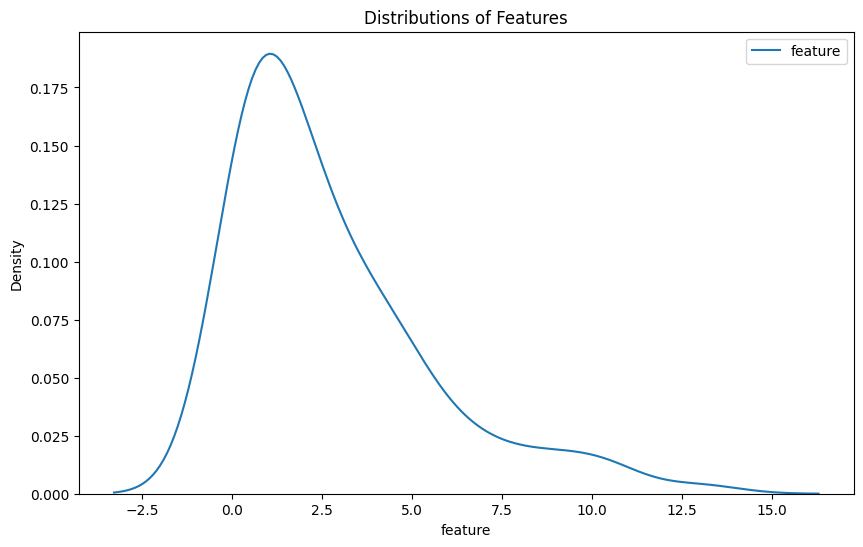

In [6]:
# 정규분포 시각화 (하나의 그래프에 선형 그래프만)
plt.figure(figsize=(10, 6))

sns.kdeplot(df['feature'], label='feature')

plt.title('Distributions of Features')
plt.legend()
plt.show()

In [ ]:
## kdeplot(커널 밀도 추정 그래프)를 그려 데이터의 분포를 시각화하는 함수
## 원본 데이터와 변환된 데이터의 분포를 한 그래프에 비교하여 보여줍니다

def show_kde(df: pd.DataFrame, df_t:pd.DataFrame, col_name: str = 'feature'):
    
    plt.figure(figsize=(10, 6))
    
    sns.kdeplot(df[col_name], label=col_name)
    sns.kdeplot(df_t[col_name], label=f"transformed_{col_name}")

    plt.title('Distributions of Features')
    plt.legend()
    plt.show()

#### 1. 로그 변환
- 데이터의 분포를 정규 분포에 가깝게 만들기 위해 사용합니다. 주로 양의 값에 대해 적용되며, 데이터의 스케일을 줄이는 데 효과적입니다.

- `np.log(x)`
  - 직접 자연 로그를 계산하고, 0 이하의 값에서는 사용 불가능합니다.
- `np.log1p(x)`
  - \( ln(1 + x) \)를 계산하여, 작은 값에서의 정밀도를 높이고, 0이나 작은 음수에도 사용할 수 있습니다.
  - `np.log1p`는 주로 작은 값에서의 정확도를 높이기 위해 사용되며, 음수에서 안정성을 제공합니다.

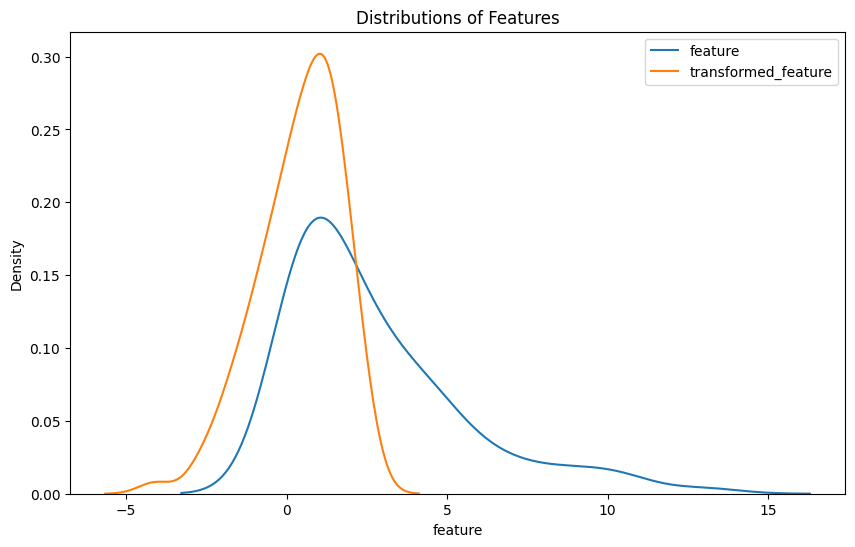

In [9]:
log_t = np.log(df)

show_kde(df, log_t, 'feature')

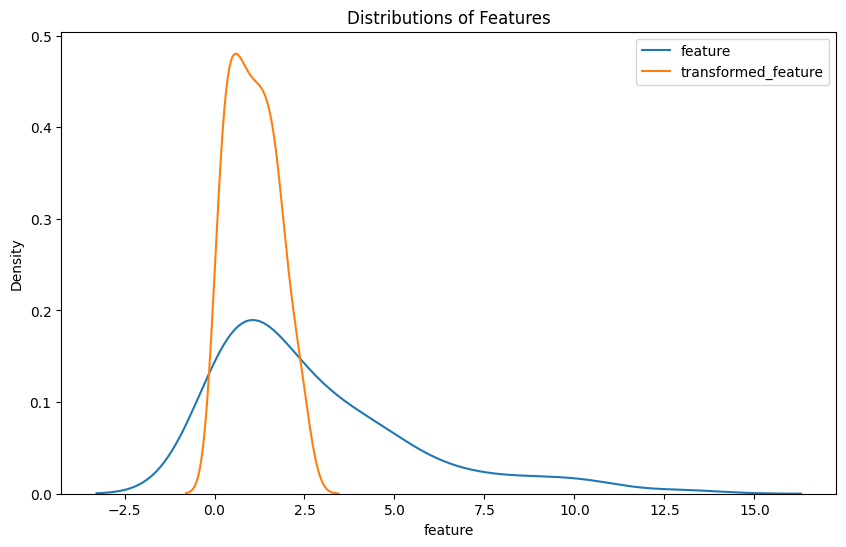

In [10]:
log1p_t = np.log1p(df)

show_kde(df, log1p_t, 'feature')

#### 2. 제곱근 변환
- 데이터의 분포를 안정화하고 왜곡을 줄이기 위해 사용됩니다. 양의 값에 대해 적용되며, 주로 데이터의 분포가 양의 편향을 가질 때 사용됩니다.

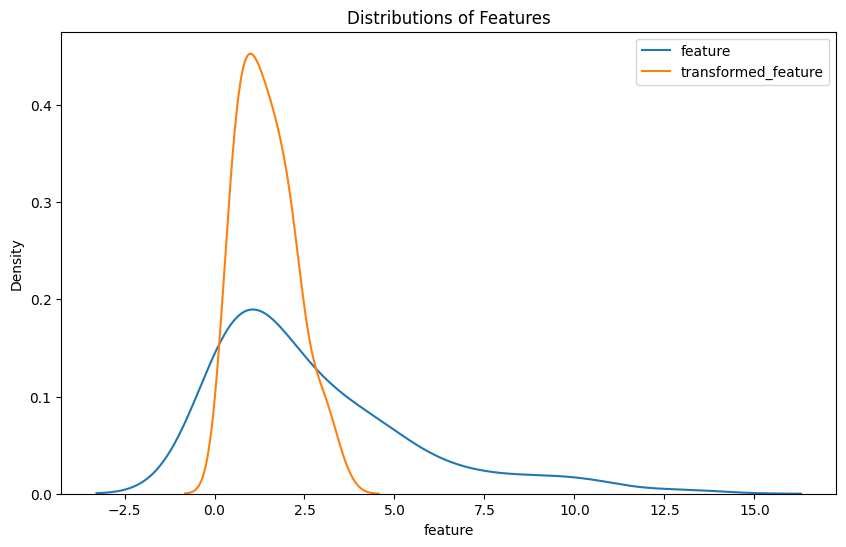

In [11]:
sqrt_t = np.sqrt(df)

show_kde(df, sqrt_t, 'feature')

#### 3. Box-Cox 변환
- 특정 파라미터 λ(lambda)에 따라 데이터의 분포를 정규화하는 변환입니다. 양의 값에 대해 적용되며, 최적의 λ값을 찾아 데이터의 분포를 정규 분포에 가깝게 만듭니다.

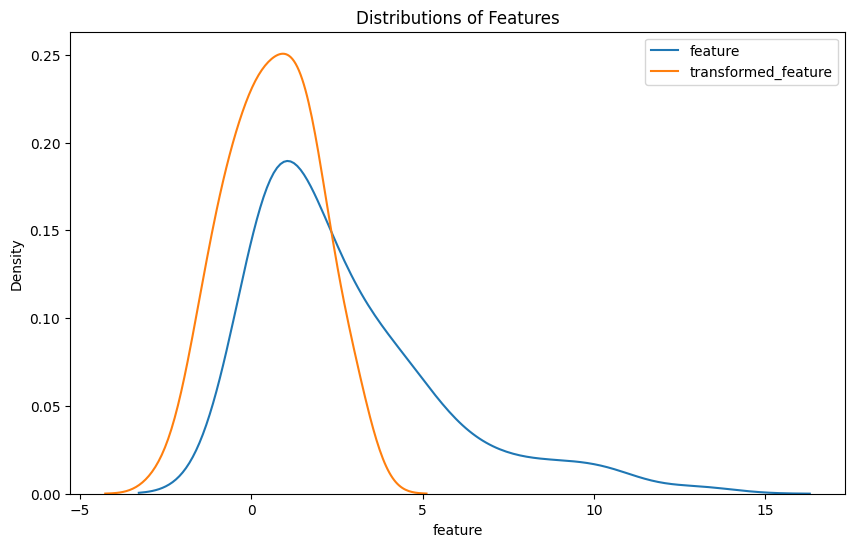

In [12]:
from scipy.stats import boxcox

boxcox_, _ = boxcox(df['feature'].tolist())
boxcox_t = pd.DataFrame(boxcox_, columns=['feature'])

show_kde(df, boxcox_t, 'feature')

#### 4. Yeo-Johnson 변환
- Box-Cox 변환의 확장으로, 음수와 0을 포함한 모든 실수 데이터에 적용할 수 있습니다. 데이터를 정규 분포에 가깝게 변환합니다.

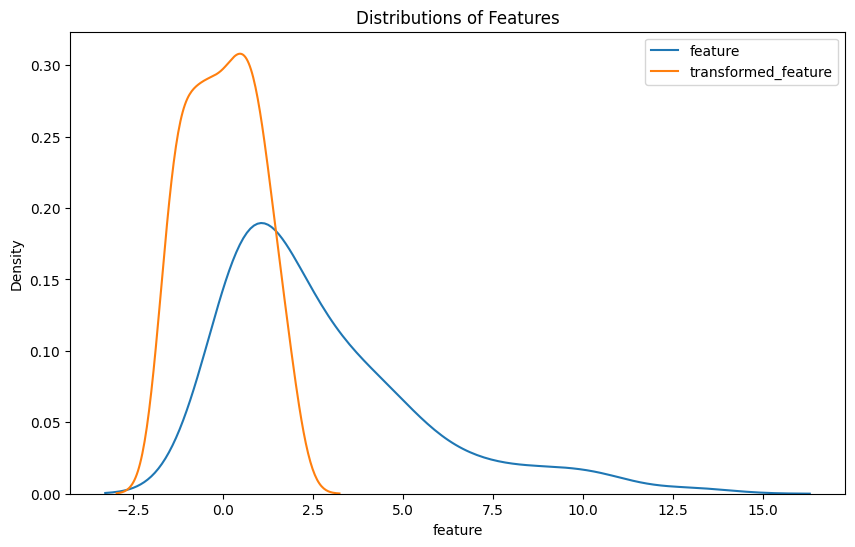

In [13]:
from sklearn.preprocessing import PowerTransformer
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html

pt = PowerTransformer(method='yeo-johnson') # box-cox
yj_ = pt.fit_transform(df[['feature']])

yj_t = pd.DataFrame(yj_, columns=['feature'])

show_kde(df, yj_t, 'feature')

#### 5. Custom 변환
- 사용자가 지정한 함수의 기능대로 데이터 변환 작업을 수행할 수 있다.

/Users/hyunsoo.lee/Desktop/Personal_Studies/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(


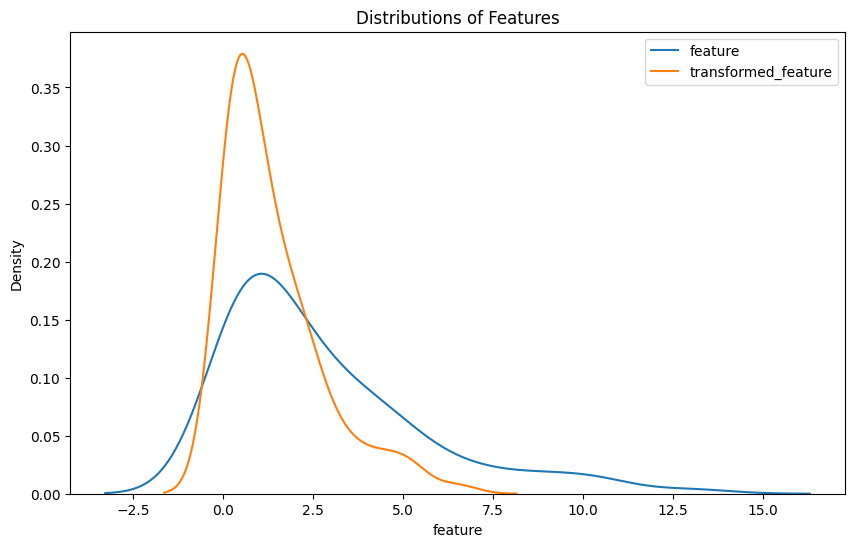

In [14]:
from sklearn.preprocessing import FunctionTransformer
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html

# log_transformer = FunctionTransformer(np.log1p, validate=True)
# data_log = log_transformer.transform(df)

def half_func(x):
    return x / 2

half_transformer = FunctionTransformer(half_func, validate=True)
data_half = half_transformer.transform(df)

data_half = pd.DataFrame(data_half, columns=['feature'])

show_kde(df, data_half, 'feature')


| 구분 | 입력 조건 | 편향 보정 강도 | 언제 사용하면 좋은지 | 비고 |
|---|---|---|---|---|
| **로그 변환** | **양수만** (log1p는 0 포함 가능) | 강함 (오른쪽 꼬리를 크게 압축) | 오른쪽으로 심하게 치우친 데이터 (소득, 인구수, 매출 등) | 가장 직관적이고 널리 사용됨 |
| **제곱근 변환** | **0 이상** | 중간 (로그보다 완만하게 압축) | 약~중간 정도의 오른쪽 편향, 카운트 데이터 (방문 횟수, 클릭 수 등) | 로그 변환이 너무 강할 때 대안 |
| **Box-Cox 변환** | **양수만** | λ를 자동 탐색하여 최적 보정 | 양수 데이터에서 최적의 정규분포 변환이 필요할 때 | λ=0이면 로그, λ=0.5이면 제곱근과 유사 |
| **Yeo-Johnson 변환** | **제한 없음** (음수·0 포함) | λ를 자동 탐색하여 최적 보정 | 음수가 포함된 데이터도 정규분포로 변환하고 싶을 때 | Box-Cox의 상위호환, 실무에서 가장 범용적 |
| **Custom 변환** | 함수에 따라 다름 | 함수에 따라 다름 | 도메인 지식에 기반한 특수 변환이 필요할 때 (예: 역수, 제곱, 지수 등) | FunctionTransformer로 파이프라인에 통합 가능 |